### Loading the Data, Importing Necessary Libraries, and Displaying Basic Info to Understand the Data.

In [ ]:
# Initial data loading and examination
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Reading the dataset
df = pd.read_csv('Healthcare Dataset.csv')

# Displaying initial info and missing values
print("Initial Dataset Info:")
df.info()
print("\
Missing Values Count:")
print(df.isnull().sum())
print("\
Initial Sample of Data:")
df

Initial Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PatientID           5000 non-null   object 
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   object 
 3   Region              5000 non-null   object 
 4   Diagnosis           4301 non-null   object 
 5   TreatmentPlan       4144 non-null   object 
 6   TreatmentSuccess    3327 non-null   object 
 7   Hospital            2502 non-null   object 
 8   Insurance Provider  3720 non-null   object 
 9   Billing Amount      4506 non-null   float64
 10  Admission Type      3718 non-null   object 
 11  Date of Admission   4776 non-null   object 
 12  Discharge Date      4776 non-null   object 
 13  Test Results        3758 non-null   object 
 14  Medical Condition   3975 non-null   object 
dtypes: float64(1), int64(1), object(1

,PatientID,Age,Gender,Region,Diagnosis,TreatmentPlan,TreatmentSuccess,Hospital,Insurance Provider,Billing Amount,Admission Type,Date of Admission,Discharge Date,Test Results,Medical Condition
0,633cf583-b55b-4171-af86-8ce48d5f5f9c,7,Male,East,Hypertension,Medication,Successful,NaN,Provider C,5945.00,NaN,2022-02-03,2023-07-08,NaN,NaN
1,80b62dc8-c8f4-4812-9239-2b12ede2e10f,14,Male,Central,Cancer,Lifestyle Changes,NaN,NaN,Provider C,725.46,Walk-in,2021-10-20,2023-06-01,NaN,Improving
2,7ff95e96-fd92-4ce1-acaf-5e34ca51a625,87,Female,East,Diabetes,Surgery,Failed,"Coffey, Doyle and Peters",NaN,1686.87,Scheduled,2023-06-25,2023-12-05,NaN,Deteriorating
3,6d9cd159-438b-4871-8f6c-e4decef02582,32,Female,East,NaN,Therapy,NaN,NaN,Provider C,6157.73,NaN,2020-11-23,2024-04-02,Positive,Improving
4,434cf5a4-c961-44d2-94a1-db5e29685c69,81,Female,North,Diabetes,Surgery,Successful,NaN,Provider B,1154.08,NaN,2023-01-01,2024-11-01,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,39b7f718-64c5-4420-9012-cfb800f21da0,23,Female,Central,Hypertension,Observation,Failed,Freeman LLC,Provider B,9227.52,Emergency,NaN,NaN,Inconclusive,Improving
4996,85fd94f4-eba8-4749-9e13-9e4b0d269eba,73,Female,East,Asthma,Surgery,Failed,NaN,NaN,7509.55,Walk-in,2024-02-20,2024-03-30,Inconclusive,Stable
4997,da5c87bb-bb34-4752-8d51-11f9cc481cd2,11,Male,South,Heart Disease,NaN,Failed,NaN,Provider B,7936.33,NaN,2024-07-13,2024-07-21,Positive,Deteriorating
4998,a051bdd3-1662-4bb0-970c-bb777a230bdf,83,Female,North,Heart Disease,Medication,Failed,"Price, Villarreal and Johnson",Provider C,3525.85,Emergency,2022-06-15,2023-06-05,Positive,Improving


#### Code Explanation

The code snippet above loads a healthcare dataset, checks for missing values, and displays the initial structure and sample of the data.

## TASK 1: Data Cleaning and Preprocessing:

For the cleaning process, we should understand that this is a health care dataset, and as such very sensitive. Therefore, in terms of filling missing values, it is best to leave non numerical columns like `Diagnosis`, `TreatmentPlan`, `TreatmentSuccess` etc. as unknown if not specified.

This is to ensure integity and to avoid assumptions that may negatively impact the health of patiients or the operations of the health care institution as well as insurance providers.

Best practice would be to contact key stakeholders, explain findings based on the missing values and request the data if it is availabe. Also, we should note that ommissions may be mistakes made during data entry. If the data is not available, it would be best to leave these fields as "Unknown" or "Not Provided", or "Not Specified" (Whatever suits the case)

In [ ]:
df_copy = df.copy()

In [ ]:
df_copy

,PatientID,Age,Gender,Region,Diagnosis,TreatmentPlan,TreatmentSuccess,Hospital,Insurance Provider,Billing Amount,Admission Type,Date of Admission,Discharge Date,Test Results,Medical Condition
0,633cf583-b55b-4171-af86-8ce48d5f5f9c,7,Male,East,Hypertension,Medication,Successful,NaN,Provider C,5945.00,NaN,2022-02-03,2023-07-08,NaN,NaN
1,80b62dc8-c8f4-4812-9239-2b12ede2e10f,14,Male,Central,Cancer,Lifestyle Changes,NaN,NaN,Provider C,725.46,Walk-in,2021-10-20,2023-06-01,NaN,Improving
2,7ff95e96-fd92-4ce1-acaf-5e34ca51a625,87,Female,East,Diabetes,Surgery,Failed,"Coffey, Doyle and Peters",NaN,1686.87,Scheduled,2023-06-25,2023-12-05,NaN,Deteriorating
3,6d9cd159-438b-4871-8f6c-e4decef02582,32,Female,East,NaN,Therapy,NaN,NaN,Provider C,6157.73,NaN,2020-11-23,2024-04-02,Positive,Improving
4,434cf5a4-c961-44d2-94a1-db5e29685c69,81,Female,North,Diabetes,Surgery,Successful,NaN,Provider B,1154.08,NaN,2023-01-01,2024-11-01,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,39b7f718-64c5-4420-9012-cfb800f21da0,23,Female,Central,Hypertension,Observation,Failed,Freeman LLC,Provider B,9227.52,Emergency,NaN,NaN,Inconclusive,Improving
4996,85fd94f4-eba8-4749-9e13-9e4b0d269eba,73,Female,East,Asthma,Surgery,Failed,NaN,NaN,7509.55,Walk-in,2024-02-20,2024-03-30,Inconclusive,Stable
4997,da5c87bb-bb34-4752-8d51-11f9cc481cd2,11,Male,South,Heart Disease,NaN,Failed,NaN,Provider B,7936.33,NaN,2024-07-13,2024-07-21,Positive,Deteriorating
4998,a051bdd3-1662-4bb0-970c-bb777a230bdf,83,Female,North,Heart Disease,Medication,Failed,"Price, Villarreal and Johnson",Provider C,3525.85,Emergency,2022-06-15,2023-06-05,Positive,Improving


In [ ]:
# Converting date columns to datetime
df_copy['Date of Admission'] = pd.to_datetime(df_copy['Date of Admission'])
df_copy['Discharge Date'] = pd.to_datetime(df_copy['Discharge Date'])

# Filling missing values appropriately
df_copy['Diagnosis'].fillna('Unknown', inplace=True)
df_copy['TreatmentPlan'].fillna('Not Specified', inplace=True)
df_copy['TreatmentSuccess'].fillna('Unknown', inplace=True)
df_copy['Hospital'].fillna('Not Recorded', inplace=True)
df_copy['Insurance Provider'].fillna('Not Provided', inplace=True)
df_copy['Admission Type'].fillna('Not Specified', inplace=True)
df_copy['Test Results'].fillna('Not Available', inplace=True)
df_copy['Medical Condition'].fillna('Not Recorded', inplace=True)

# Removing any ages that don't make sense (e.g., negative or extremely high)
df_copy = df_copy[(df_copy['Age'] >= 0) & (df['Age'] <= 120)]

# Checking for duplicate PatientIDs
duplicates = df_copy[df_copy.duplicated(subset=['PatientID'], keep=False)]
print("Number of duplicate PatientIDs:", len(duplicates))

# # Basic statistics of numerical columns after cleaning
# print("\
# Numerical columns summary after cleaning:")
# print(df_copy[['Age', 'Billing Amount']].describe())

Number of duplicate PatientIDs: 0


In [ ]:
df_copy

,PatientID,Age,Gender,Region,Diagnosis,TreatmentPlan,TreatmentSuccess,Hospital,Insurance Provider,Billing Amount,Admission Type,Date of Admission,Discharge Date,Test Results,Medical Condition
0,633cf583-b55b-4171-af86-8ce48d5f5f9c,7,Male,East,Hypertension,Medication,Successful,Not Recorded,Provider C,5945.00,Not Specified,2022-02-03,2023-07-08,Not Available,Not Recorded
1,80b62dc8-c8f4-4812-9239-2b12ede2e10f,14,Male,Central,Cancer,Lifestyle Changes,Unknown,Not Recorded,Provider C,725.46,Walk-in,2021-10-20,2023-06-01,Not Available,Improving
2,7ff95e96-fd92-4ce1-acaf-5e34ca51a625,87,Female,East,Diabetes,Surgery,Failed,"Coffey, Doyle and Peters",Not Provided,1686.87,Scheduled,2023-06-25,2023-12-05,Not Available,Deteriorating
3,6d9cd159-438b-4871-8f6c-e4decef02582,32,Female,East,Unknown,Therapy,Unknown,Not Recorded,Provider C,6157.73,Not Specified,2020-11-23,2024-04-02,Positive,Improving
4,434cf5a4-c961-44d2-94a1-db5e29685c69,81,Female,North,Diabetes,Surgery,Successful,Not Recorded,Provider B,1154.08,Not Specified,2023-01-01,2024-11-01,Not Available,Not Recorded
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,39b7f718-64c5-4420-9012-cfb800f21da0,23,Female,Central,Hypertension,Observation,Failed,Freeman LLC,Provider B,9227.52,Emergency,NaT,NaT,Inconclusive,Improving
4996,85fd94f4-eba8-4749-9e13-9e4b0d269eba,73,Female,East,Asthma,Surgery,Failed,Not Recorded,Not Provided,7509.55,Walk-in,2024-02-20,2024-03-30,Inconclusive,Stable
4997,da5c87bb-bb34-4752-8d51-11f9cc481cd2,11,Male,South,Heart Disease,Not Specified,Failed,Not Recorded,Provider B,7936.33,Not Specified,2024-07-13,2024-07-21,Positive,Deteriorating
4998,a051bdd3-1662-4bb0-970c-bb777a230bdf,83,Female,North,Heart Disease,Medication,Failed,"Price, Villarreal and Johnson",Provider C,3525.85,Emergency,2022-06-15,2023-06-05,Positive,Improving


#### Code Explanation
The code snippet above processes the healthcare dataset by converting date columns to datetime, filling missing values, handling outliers in age, checking for duplicates.

#### Let me explain the cleaning approach taken for each column so far:

**Categorical Variables:**

- `Diagnosis`: Filled with 'Unknown' as it's better to explicitly mark missing diagnoses

- `TreatmentPlan`: Used 'Not Specified' to indicate absence of documented plan

- `TreatmentSuccess`: Marked as 'Unknown' since outcomes can't be assumed

- `Hospital`: 'Not Recorded' used for missing hospital names

- `Insurance Provider`: 'Not Provided' indicates missing insurance information

- `Admission Type`: 'Not Specified' for undocumented admission types

- `Test Results`: 'Not Available' for missing test data

- `Medical Condition`: 'Not Recorded' for undocumented conditions

**Numerical Variables:**
- `Age`: Removed invalid ages (kept only 0-120 range)

**Dates:**
- Converted `Date of Admission` and `Discharge Date` to datetime format for proper temporal analysis

**Data Integrity:**
- Checked and confirmed no duplicate `PatientID`s exist
- Preserved original `PatientID` values as they are unique identifiers

### Handling NaN in the "Billing Amount" Column

**The best approach would be to group the data by relevant categorical variables that influence billing patterns and then fill the missing values using the group mean or median of Billing Amount.**

**Suggested Grouping Variables**
- `Hospital`: Different hospitals may have distinct billing rates for treatments.
- `Diagnosis`: Specific diagnoses can result in similar billing amounts for treatments.
- `TreatmentPlan`: Each treatment plan is likely associated with a standard cost.
- `Insurance Provider`: Insurance agreements might influence billing rates.

**Reasoning Behind the Approach**
- Grouping by related features ensures **logical consistency**: Patients with the same hospital, diagnosis, treatment plan, and insurance provider are likely to have comparable billing amounts. Grouping leverages this relationship to fill the missing values.
* Group **median** over mean **for robustness**: Since medical billing may contain outliers (e.g., abnormally high billing for rare cases), the median is more robust than the mean.


In [ ]:
# Filling NaN values in Billing Amount with the group median
df_copy['Billing Amount'] = df_copy.groupby(
    ['Hospital', 'Diagnosis', 'TreatmentPlan', 'Insurance Provider']
)['Billing Amount'].transform(lambda x: x.fillna(x.median()))

# Print the result to verify
print("Missing values filled successfully!")

Missing values filled successfully!


C:\Users\USER\AppData\Local\Temp\ipykernel_13432\3929665049.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy['Billing Amount'] = df_copy.groupby(


#### Justification for Filling Missing Billing Amounts

The `Billing Amount` column in the healthcare dataset may vary based on key factors such as:
- The **hospital** where the patient received treatment,
- The **diagnosis** and its associated treatment cost,
- The **treatment plan** selected for the patient,
- The **insurance provider**, which may negotiate specific billing rates.

By grouping the data using these features, we ensure that missing values are filled with contextually appropriate values derived from patients with similar profiles.

Additionally:
- **Median** is chosen over mean because it is less sensitive to outliers, ensuring that the filled values are not skewed by extreme billing amounts.
- This approach leverages the natural structure of the data, preserving the integrity of the dataset for further analysis.


#### Advantages of This Approach
1. Data-Driven: The grouping is based on features that naturally impact billing amounts, leading to more accurate imputations.
2. Scalable: Works efficiently for large datasets with categorical features.
3. Preserves Data Integrity: Avoids introducing unrealistic or biased values.

**NOTE:**
If there are groups where all Billing Amount values are "NaN", they will remain "NaN". Therefore, further imputation using overall median may be applied as a fallback.

In [ ]:
# Displaying rows where Billing Amount is null
missing_billing = df_copy[df_copy['Billing Amount'].isnull()]

In [ ]:
missing_billing

,PatientID,Age,Gender,Region,Diagnosis,TreatmentPlan,TreatmentSuccess,Hospital,Insurance Provider,Billing Amount,Admission Type,Date of Admission,Discharge Date,Test Results,Medical Condition
18,7d274e81-839b-4ccc-86a1-4f8790917b39,71,Male,East,Hypertension,Medication,Successful,Oconnor-Morgan,Not Provided,NaN,Not Specified,2021-09-15,2024-11-11,Inconclusive,Critical
45,587a359e-d2af-4f7f-805e-3c5dbbe8bfbb,5,Female,Central,Unknown,Lifestyle Changes,Failed,"Perez, Simpson and Wagner",Provider B,NaN,Walk-in,2021-11-03,2022-08-06,Inconclusive,Deteriorating
48,a3168f75-b2aa-4ad2-9f18-0bb5284d2cbc,31,Male,South,Asthma,Medication,Unknown,"Thomas, Forbes and Wheeler",Not Provided,NaN,Walk-in,2023-03-25,2024-05-05,Positive,Not Recorded
51,9fd32284-235b-44f2-ad6c-d0fd115ff483,71,Female,North,Unknown,Surgery,Failed,Bell-Carter,Provider B,NaN,Walk-in,2022-08-18,2023-10-08,Inconclusive,Stable
93,bb516124-7106-47fd-96e9-77db0ecfa794,26,Female,South,Diabetes,Medication,Successful,Evans-Pierce,Provider A,NaN,Not Specified,2020-11-18,2024-10-28,Inconclusive,Improving
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4928,d74e66aa-17bd-42b7-9fc4-ce330032ef92,88,Male,West,Unknown,Surgery,Unknown,"Mccullough, Lewis and Grant",Not Provided,NaN,Scheduled,2021-04-30,2021-11-18,Not Available,Critical
4936,e473f417-1b8a-4171-8be4-3d26f13d15f2,21,Female,North,Hypertension,Lifestyle Changes,Successful,"Anthony, Hernandez and Hall",Provider A,NaN,Walk-in,2022-03-28,2023-05-18,Inconclusive,Critical
4963,7239abb6-2c91-4793-9612-caa24a577306,3,Male,East,Diabetes,Not Specified,Successful,"Burch, Jensen and Pena",Provider B,NaN,Walk-in,2024-01-08,2024-04-16,Inconclusive,Improving
4964,0949d9e5-984e-4f19-ad36-27c748ec47e7,45,Male,South,Heart Disease,Medication,Successful,Douglas Group,Provider C,NaN,Walk-in,2021-01-03,2023-10-21,Positive,Deteriorating


In [ ]:
# Alternative way to check for NaT
missing_billing[missing_billing['Date of Admission'].isna()]

,PatientID,Age,Gender,Region,Diagnosis,TreatmentPlan,TreatmentSuccess,Hospital,Insurance Provider,Billing Amount,Admission Type,Date of Admission,Discharge Date,Test Results,Medical Condition
378,ec5cde76-02cb-4421-ac12-7c6ae13d01a7,30,Male,Central,Unknown,Surgery,Unknown,Ellis and Sons,Provider C,NaN,Scheduled,NaT,NaT,Not Available,Critical
1730,ba9a0f17-2f8b-4ab4-b9b6-2d6bc5becc8f,44,Male,West,Diabetes,Therapy,Successful,Smith-Castillo,Provider C,NaN,Not Specified,NaT,NaT,Negative,Deteriorating
1809,d46724d3-aae3-4618-b424-b76f0d764577,25,Female,North,Flu,Lifestyle Changes,Failed,Santos-Wood,Provider A,NaN,Not Specified,NaT,NaT,Negative,Improving
2550,cc331f68-43ad-47e5-af20-a907bbfa1397,5,Female,Central,Heart Disease,Therapy,Unknown,"Keller, Hughes and Rowe",Provider C,NaN,Not Specified,NaT,NaT,Inconclusive,Critical
2575,b6c5a099-dd58-4293-9b18-b1ee19e75907,16,Female,East,Cancer,Surgery,Unknown,Riley Group,Provider A,NaN,Not Specified,NaT,NaT,Not Available,Critical
3086,6ac95a66-70f9-433d-9c89-3ac197c7e34d,31,Male,South,Heart Disease,Therapy,Failed,Stark Group,Provider A,NaN,Not Specified,NaT,NaT,Inconclusive,Critical
3098,fa7c96f8-8cab-4756-8e6a-3e4b79a4ac41,12,Male,North,Hypertension,Not Specified,Unknown,"Perez, James and Wise",Provider A,NaN,Walk-in,NaT,NaT,Not Available,Improving
4151,01675890-4176-40d7-8a52-993a2a7a498a,73,Female,South,Asthma,Surgery,Failed,Williams-Ramirez,Not Provided,NaN,Not Specified,NaT,NaT,Negative,Deteriorating
4822,223d196b-c7d0-415e-834f-94ded09e306f,39,Male,West,Cancer,Surgery,Successful,"Guzman, Harrison and Hernandez",Provider A,NaN,Walk-in,NaT,NaT,Negative,Improving


In [ ]:
# Alternative way to check for NaT
df_copy[df_copy['Date of Admission'].isna()]

,PatientID,Age,Gender,Region,Diagnosis,TreatmentPlan,TreatmentSuccess,Hospital,Insurance Provider,Billing Amount,Admission Type,Date of Admission,Discharge Date,Test Results,Medical Condition
33,3c6baecf-a8a8-424e-b3bc-55b3485972f6,45,Female,West,Heart Disease,Medication,Unknown,Not Recorded,Not Provided,6715.585,Scheduled,NaT,NaT,Positive,Stable
43,d876cc17-638c-4ed6-801c-c2c65d383d60,27,Female,East,Heart Disease,Therapy,Failed,Williamson Inc,Provider A,1181.310,Emergency,NaT,NaT,Positive,Critical
67,fe931772-db11-4488-b47a-465b3a5d7243,46,Male,East,Heart Disease,Observation,Failed,Houston Group,Provider A,4629.760,Scheduled,NaT,NaT,Not Available,Deteriorating
94,f3ba8312-2ea6-4f27-809e-3aeb004df261,70,Male,Central,Diabetes,Surgery,Successful,"Smith, Gonzales and Smith",Provider C,2636.170,Emergency,NaT,NaT,Not Available,Not Recorded
99,8fd63861-56cc-4e23-963d-46a89e111672,80,Female,East,Diabetes,Observation,Failed,Not Recorded,Not Provided,3523.130,Not Specified,NaT,NaT,Inconclusive,Not Recorded
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4934,0c7f0539-fdec-4ffc-a862-14d2e7e3c253,80,Male,East,Diabetes,Observation,Successful,Not Recorded,Not Provided,2174.240,Scheduled,NaT,NaT,Negative,Not Recorded
4951,940cb5fc-9a1a-4f7f-90e0-2fe3bfded2c9,80,Male,North,Unknown,Lifestyle Changes,Successful,Not Recorded,Provider C,9004.660,Not Specified,NaT,NaT,Positive,Stable
4973,33493415-c285-4b73-8da5-ef7d2915882d,3,Female,North,Flu,Medication,Failed,Jackson Inc,Provider A,6326.540,Scheduled,NaT,NaT,Positive,Not Recorded
4977,ce07a2a6-8a14-43c4-8cf8-689a13920705,77,Male,South,Cancer,Not Specified,Failed,Wright Ltd,Provider B,1528.120,Scheduled,NaT,NaT,Not Available,Not Recorded


### To fill the remaining missing values in the `Billing Amount` column, we will use regression to predict these missing values. We'll build a simple machine learning model to this effect.

In [ ]:
# Import libraries for data manipulation, machine learning, and visualization

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

#### Preparing the data, we'll separate the dataset into rows with and without missing `Billing Amount` values.

In [ ]:
# Separate rows where Billing Amount is NaN and where it's not

df_missing = df_copy[df_copy['Billing Amount'].isnull()]  # Rows with NaN
df_not_missing = df_copy[df_copy['Billing Amount'].notnull()]  # Rows without NaN

#### Next, We'll Preprocess the Data
- Here, we drop irrelevant columns
- Convert categorical variables into dummy/indicator variables
- Then align the columns of both datasets to ensure they match

In [ ]:
# Dropping irrelevant columns for prediction (like PatientID, which is unique and non-numerical)
columns_to_drop = ['PatientID', 'Date of Admission', 'Discharge Date', 'Test Results']
df_not_missing = df_not_missing.drop(columns=columns_to_drop, axis=1)
df_missing = df_missing.drop(columns=columns_to_drop, axis=1)

# Converting categorical variables into dummy variables
df_not_missing = pd.get_dummies(df_not_missing, drop_first=True)
df_missing = pd.get_dummies(df_missing, drop_first=True)

# Aligning the columns of both datasets to ensure they match
df_missing = df_missing.reindex(columns=df_not_missing.columns, fill_value=0)

#### Then define our Features (X) and Target (y) variables

In [ ]:
# Features (all columns except 'Billing Amount') and target ('Billing Amount')
y = df_not_missing['Billing Amount']
X = df_not_missing.drop('Billing Amount', axis=1)

#### After which We split our Data for Training and Testing

In [ ]:
# Splitting data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Training the Model Commences


In [ ]:
# Initialising a Random Forest Regressor
model = RandomForestRegressor(random_state=42, n_estimators=100)

# Training the model on the training set
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

#### Our Trained Model Needs to be Evaluated to See How Well it is Performing after Making Predictions

In [ ]:
# Making predictions on the test set
y_pred = model.predict(X_test)

# Calculating the mean squared error (MSE) to evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 7369731.45


In [ ]:
# Calculate RMSE
rmse = np.sqrt(mse)

# Print RMSE
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Root Mean Squared Error (RMSE): 2714.72


### Model Performance Evaluation

##### RMSE Interpretation
The **Root Mean Squared Error (RMSE)** for the model is approximately **2715.63**. This value helps us understand the model's prediction accuracy in the same units as the target variable (`Billing Amount`).

On average, the model's predictions deviate from the actual `Billing Amount` values by approximately **2715.63**.

##### Comparison to Billing Amount Range
- The `Billing Amount` column spans values from **hundreds** to **thousands**, with the highest figure being **9999.93**.
- An error of **2715.63** is relatively high compared to the range, indicating the model struggles with prediction accuracy for some data points.

##### Possible Causes of High RMSE
1. **Limited Features**:
   - The predictors (e.g., `Hospital`, `Diagnosis`, `TreatmentPlan`) may not have strong relationships with the `Billing Amount`.
2. **Data Variability**:
   - There may be significant randomness in billing amounts, making them harder to predict.
3. **Noise or Outliers**:
   - Inconsistencies or extreme values in the dataset could affect the model's performance.

##### Next Steps for Improvement
To improve the model's performance:
1. **Add More Relevant Features**:
   - Introduce additional predictors that could influence the `Billing Amount` (e.g., `duration of hospital stay`, derived from `Date of Admission` and `Discharge Date`).
2. **Feature Engineering**:
   - Create new features that capture hidden patterns in the data.
3. **Experiment with Advanced Algorithms**:
   - Use algorithms like **Random Forests** or **Gradient Boosting**, which are better at capturing complex relationships.

#### Conclusion
While the model provides some predictive power, the high RMSE indicates there is room for improvement. The current predictions are suitable as rough estimates but may not be reliable for precise billing purposes.


#### Checking for outliers

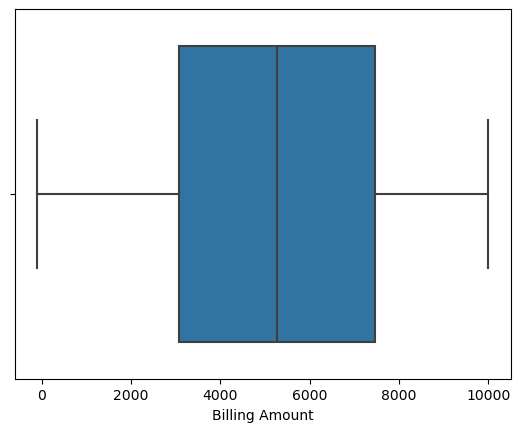

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=df_copy['Billing Amount'])
plt.show()

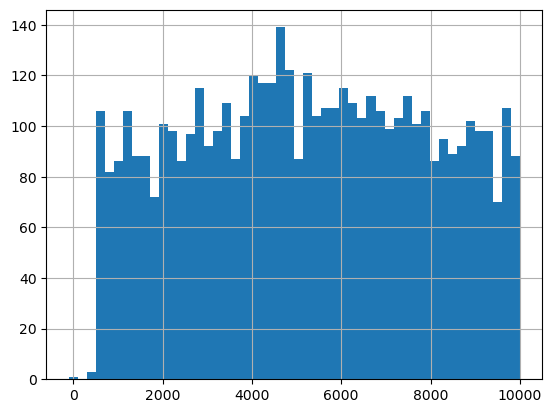

In [ ]:
df_copy['Billing Amount'].hist(bins=50)
plt.show()

In [ ]:
# Using the Interquartile Range (IQR) method to define outliers as values outside 1.5 times the IQR below Q1 or above Q3.

Q1 = df_copy['Billing Amount'].quantile(0.25)
Q3 = df_copy['Billing Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify the outliers
outliers = df_copy[(df_copy['Billing Amount'] < lower_bound) | (df_copy['Billing Amount'] > upper_bound)]
print(outliers)

Empty DataFrame
Columns: [PatientID, Age, Gender, Region, Diagnosis, TreatmentPlan, TreatmentSuccess, Hospital, Insurance Provider, Billing Amount, Admission Type, Date of Admission, Discharge Date, Test Results, Medical Condition]
Index: []


#### From the above IQR method to check for outliers, we found that;
**No Outliers were Found:** An `Empty DataFrame`. The absence of outliers means that all the values fall within a normal range, which could be a good sign for our model. It suggests that the data is fairly well-behaved and doesn't have extreme values that could negatively impact our analysis.

In [ ]:
from scipy.stats import zscore

# Calculate Z-scores
df_copy['z_score'] = zscore(df['Billing Amount'])

# Identify outliers based on Z-score
outliers = df_copy[df_copy['z_score'].abs() > 3]
print(outliers)

Empty DataFrame
Columns: [PatientID, Age, Gender, Region, Diagnosis, TreatmentPlan, TreatmentSuccess, Hospital, Insurance Provider, Billing Amount, Admission Type, Date of Admission, Discharge Date, Test Results, Medical Condition, z_score]
Index: []


C:\Users\USER\AppData\Local\Temp\ipykernel_13432\1078487147.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy['z_score'] = zscore(df['Billing Amount'])


#### The `Z-score` method also confirms it.

#### In this Case, We'll Perform Feature Engineering

#### Check the Data for Non-Numeric Columns


In [ ]:
# Inspecting the training data to identify non-numeric columns.
print(X_train.dtypes)

Age                                int64
Gender_Male                         bool
Region_East                         bool
Region_North                        bool
Region_South                        bool
                                   ...  
Admission Type_Walk-in              bool
Medical Condition_Deteriorating     bool
Medical Condition_Improving         bool
Medical Condition_Not Recorded      bool
Medical Condition_Stable            bool
Length: 2175, dtype: object


#### Handling Categorical Variables

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Apply OneHotEncoding to categorical columns
categorical_columns = X_train.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

encoded_features = pd.DataFrame(
    encoder.fit_transform(X_train[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_train.index
)

# Drop original categorical columns and append the encoded ones
X_train = X_train.drop(columns=categorical_columns)
X_train = pd.concat([X_train, encoded_features], axis=1)


C:\Users\USER\anaconda3\envs\practice04_3_10_13\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
# Repeating the same transformation for our test set (X_test) using the encoder already fitted on the training data:

encoded_features_test = pd.DataFrame(
    encoder.transform(X_test[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X_test.index
)

X_test = X_test.drop(columns=categorical_columns)
X_test = pd.concat([X_test, encoded_features_test], axis=1)

Ensuring Data Consistency

In [ ]:
print(X_train.columns.difference(X_test.columns))
print(X_test.columns.difference(X_train.columns))

Index([], dtype='object')
Index([], dtype='object')


In [ ]:
X_train.dtypes
# print(X_test.dtypes)

Age                                int64
Gender_Male                         bool
Region_East                         bool
Region_North                        bool
Region_South                        bool
                                   ...  
Admission Type_Walk-in              bool
Medical Condition_Deteriorating     bool
Medical Condition_Improving         bool
Medical Condition_Not Recorded      bool
Medical Condition_Stable            bool
Length: 2175, dtype: object

In [ ]:
X_train

,Age,Gender_Male,Region_East,Region_North,Region_South,Region_West,Diagnosis_Cancer,Diagnosis_Diabetes,Diagnosis_Flu,Diagnosis_Heart Disease,...,Insurance Provider_Provider A,Insurance Provider_Provider B,Insurance Provider_Provider C,Admission Type_Not Specified,Admission Type_Scheduled,Admission Type_Walk-in,Medical Condition_Deteriorating,Medical Condition_Improving,Medical Condition_Not Recorded,Medical Condition_Stable
2337,51,True,False,False,False,True,True,False,False,False,...,True,False,False,False,True,False,False,False,False,True
1574,40,False,False,True,False,False,False,False,True,False,...,True,False,False,False,False,True,False,False,False,False
4580,4,True,False,False,False,True,False,False,False,False,...,True,False,False,False,True,False,False,False,False,True
2586,89,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
1956,90,False,False,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4654,54,True,False,False,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
493,16,False,False,True,False,False,False,True,False,False,...,False,True,False,False,False,True,False,True,False,False
3243,33,False,False,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
3962,93,True,True,False,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,True


In [ ]:
X_test

,Age,Gender_Male,Region_East,Region_North,Region_South,Region_West,Diagnosis_Cancer,Diagnosis_Diabetes,Diagnosis_Flu,Diagnosis_Heart Disease,...,Insurance Provider_Provider A,Insurance Provider_Provider B,Insurance Provider_Provider C,Admission Type_Not Specified,Admission Type_Scheduled,Admission Type_Walk-in,Medical Condition_Deteriorating,Medical Condition_Improving,Medical Condition_Not Recorded,Medical Condition_Stable
4007,76,False,True,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
1132,91,False,False,False,True,False,False,True,False,False,...,False,False,True,False,False,True,False,False,True,False
313,14,False,False,False,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
2149,9,False,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1787,68,False,False,False,False,False,True,False,False,False,...,True,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1707,58,True,False,False,True,False,False,True,False,False,...,True,False,False,False,False,False,True,False,False,False
4551,24,True,False,False,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
1724,81,True,False,False,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
3866,23,False,False,False,False,True,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False


In [ ]:
y_train

2337    3716.74
1574    7426.97
4580    4190.59
2586    3046.41
1956     557.69
         ...   
4654    5491.87
493     6898.99
3243    7754.51
3962     674.98
903     3149.33
Name: Billing Amount, Length: 3800, dtype: float64

In [ ]:
y_test

4007    4020.91
1132    6351.07
313     9592.67
2149    1764.76
1787    2408.52
         ...   
1707    5519.53
4551    1165.17
1724    9820.69
3866    9403.08
3202    9879.91
Name: Billing Amount, Length: 951, dtype: float64

#### We will have to convert the boolean data types in our training and testing sets to numeric dtypes for our model to be able to process it.

In [ ]:
# Checking boolean columns

bool_columns = X_train.select_dtypes(include=['bool']).columns
print("Boolean columns:", bool_columns)

Boolean columns: Index(['Gender_Male', 'Region_East', 'Region_North', 'Region_South',
       'Region_West', 'Diagnosis_Cancer', 'Diagnosis_Diabetes',
       'Diagnosis_Flu', 'Diagnosis_Heart Disease', 'Diagnosis_Hypertension',
       ...
       'Insurance Provider_Provider A', 'Insurance Provider_Provider B',
       'Insurance Provider_Provider C', 'Admission Type_Not Specified',
       'Admission Type_Scheduled', 'Admission Type_Walk-in',
       'Medical Condition_Deteriorating', 'Medical Condition_Improving',
       'Medical Condition_Not Recorded', 'Medical Condition_Stable'],
      dtype='object', length=2174)


#### Convert Boolean Values to Numerical

In [ ]:
X_train[bool_columns] = X_train[bool_columns].astype(int)
X_test[bool_columns] = X_test[bool_columns].astype(int)

In [ ]:
X_train.dtypes

Age                                int64
Gender_Male                        int32
Region_East                        int32
Region_North                       int32
Region_South                       int32
                                   ...  
Admission Type_Walk-in             int32
Medical Condition_Deteriorating    int32
Medical Condition_Improving        int32
Medical Condition_Not Recorded     int32
Medical Condition_Stable           int32
Length: 2175, dtype: object

In [ ]:
X_train

,Age,Gender_Male,Region_East,Region_North,Region_South,Region_West,Diagnosis_Cancer,Diagnosis_Diabetes,Diagnosis_Flu,Diagnosis_Heart Disease,...,Insurance Provider_Provider A,Insurance Provider_Provider B,Insurance Provider_Provider C,Admission Type_Not Specified,Admission Type_Scheduled,Admission Type_Walk-in,Medical Condition_Deteriorating,Medical Condition_Improving,Medical Condition_Not Recorded,Medical Condition_Stable
2337,51,1,0,0,0,1,1,0,0,0,...,1,0,0,0,1,0,0,0,0,1
1574,40,0,0,1,0,0,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0
4580,4,1,0,0,0,1,0,0,0,0,...,1,0,0,0,1,0,0,0,0,1
2586,89,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
1956,90,0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4654,54,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
493,16,0,0,1,0,0,0,1,0,0,...,0,1,0,0,0,1,0,1,0,0
3243,33,0,0,0,0,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0
3962,93,1,1,0,0,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,1


In [ ]:
X_test

,Age,Gender_Male,Region_East,Region_North,Region_South,Region_West,Diagnosis_Cancer,Diagnosis_Diabetes,Diagnosis_Flu,Diagnosis_Heart Disease,...,Insurance Provider_Provider A,Insurance Provider_Provider B,Insurance Provider_Provider C,Admission Type_Not Specified,Admission Type_Scheduled,Admission Type_Walk-in,Medical Condition_Deteriorating,Medical Condition_Improving,Medical Condition_Not Recorded,Medical Condition_Stable
4007,76,0,1,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1
1132,91,0,0,0,1,0,0,1,0,0,...,0,0,1,0,0,1,0,0,1,0
313,14,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2149,9,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1787,68,0,0,0,0,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1707,58,1,0,0,1,0,0,1,0,0,...,1,0,0,0,0,0,1,0,0,0
4551,24,1,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
1724,81,1,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
3866,23,0,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0


In [ ]:
# # Step 1: Add or review feature engineering
# df_copy['Length_of_Stay'] = (pd.to_datetime(df_copy['Discharge Date']) - pd.to_datetime(df_copy['Date of Admission'])).dt.days
# df_copy['Age_Group'] = df_copy['Age'].apply(lambda x: 'Child' if x <= 12 else 'Teen' if x <= 19 else 'Adult' if x <= 64 else 'Senior')
# df_copy = pd.get_dummies(df_copy, columns=['Gender', 'Region', 'Age_Group', 'Insurance Provider'], drop_first=True)

# # Drop irrelevant columns
# df_copy = df_copy.drop(['PatientID', 'Date of Admission', 'Discharge Date'], axis=1)

# # Step 2: Prepare the data (same as before)
# X = df_copy[df_copy['Billing Amount'].notna()].drop('Billing Amount', axis=1)
# y = df_copy[df_copy['Billing Amount'].notna()]['Billing Amount']
# X_missing = df_copy[df_copy['Billing Amount'].isna()].drop('Billing Amount', axis=1)

# # Split the data into train and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Hyperparameter tuning for Random Forest
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best model
best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Step 4: Train and Evaluate the Best Model
# Train
best_rf.fit(X_train, y_train)

# Predict
y_pred = best_rf.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Test MSE:", mse)
print("Test RMSE:", rmse)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 500}
Test MSE: 6981664.011211672
Test RMSE: 2642.2838627240017


### Our model improved slightly, with the RMSE dropping from 2715.63 to 2642.284. Now we can go ahead to make predictions to fill the NaN values in our `Billing Amount` column.

In [ ]:
df_missing

,Age,Billing Amount,Gender_Male,Region_East,Region_North,Region_South,Region_West,Diagnosis_Cancer,Diagnosis_Diabetes,Diagnosis_Flu,...,Insurance Provider_Provider A,Insurance Provider_Provider B,Insurance Provider_Provider C,Admission Type_Not Specified,Admission Type_Scheduled,Admission Type_Walk-in,Medical Condition_Deteriorating,Medical Condition_Improving,Medical Condition_Not Recorded,Medical Condition_Stable
18,71,NaN,True,True,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
45,5,NaN,False,False,False,False,False,False,False,False,...,False,True,False,False,False,True,True,False,False,False
48,31,NaN,True,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
51,71,NaN,False,False,True,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True
93,26,NaN,False,False,False,True,False,False,True,False,...,True,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4928,88,NaN,True,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4936,21,NaN,False,False,True,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
4963,3,NaN,True,True,False,False,False,False,True,False,...,False,True,False,False,False,True,False,True,False,False
4964,45,NaN,True,False,False,True,False,False,False,False,...,False,False,True,False,False,True,True,False,False,False


In [ ]:
# Checking boolean columns

bool_columns_missing = df_missing.select_dtypes(include=['bool']).columns
print("Boolean columns:", bool_columns_missing)

Boolean columns: Index(['Gender_Male', 'Region_East', 'Region_North', 'Region_South',
       'Region_West', 'Diagnosis_Cancer', 'Diagnosis_Diabetes',
       'Diagnosis_Flu', 'Diagnosis_Heart Disease', 'Diagnosis_Hypertension',
       'Diagnosis_Unknown', 'TreatmentPlan_Medication',
       'TreatmentPlan_Not Specified', 'TreatmentPlan_Observation',
       'TreatmentPlan_Surgery', 'TreatmentPlan_Therapy',
       'TreatmentSuccess_Successful', 'TreatmentSuccess_Unknown',
       'Hospital_Crawford and Sons', 'Hospital_Evans Group',
       'Hospital_Garcia Ltd', 'Hospital_Hernandez LLC',
       'Hospital_Jackson and Sons', 'Hospital_Johnson-Williams',
       'Hospital_Jones Inc', 'Hospital_Miller Inc', 'Hospital_Miller PLC',
       'Hospital_Miranda Inc', 'Hospital_Mitchell Group', 'Hospital_Ray Ltd',
       'Hospital_Ruiz and Sons', 'Hospital_Salas Inc', 'Hospital_Santos Ltd',
       'Hospital_Scott PLC', 'Hospital_Smith LLC', 'Hospital_Smith and Sons',
       'Hospital_Tate Group', 'Hospi

In [ ]:
# Apply OneHotEncoding to categorical columns for X_missing
categorical_columns_df_missing = df_missing.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

encoded_features = pd.DataFrame(
    encoder.fit_transform(df_missing[categorical_columns]),
    columns=encoder.get_feature_names_out(categorical_columns_df_missing),
    index=df_missing.index
)

# Drop original categorical columns and append the encoded ones
df_missing = df_missing.drop(columns=categorical_columns_df_missing)
df_missing = pd.concat([df_missing, encoded_features], axis=1)

C:\Users\USER\anaconda3\envs\practice04_3_10_13\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
df_missing[bool_columns_missing] = df_missing[bool_columns_missing].astype(int)

In [ ]:
assert list(X.columns) == list(df_missing.columns), "Feature mismatch between training and prediction data!"


AssertionError: Feature mismatch between training and prediction data!

In [ ]:
# Reindex X_missing to match X
df_missing = df_missing.reindex(columns=X.columns, fill_value=0)

# Check again
assert list(X.columns) == list(df_missing.columns), "Feature mismatch still exists!"


In [ ]:
"X columns:", list(X.columns)

('X columns:',
 ['Age',
  'Gender_Male',
  'Region_East',
  'Region_North',
  'Region_South',
  'Region_West',
  'Diagnosis_Cancer',
  'Diagnosis_Diabetes',
  'Diagnosis_Flu',
  'Diagnosis_Heart Disease',
  'Diagnosis_Hypertension',
  'Diagnosis_Unknown',
  'TreatmentPlan_Medication',
  'TreatmentPlan_Not Specified',
  'TreatmentPlan_Observation',
  'TreatmentPlan_Surgery',
  'TreatmentPlan_Therapy',
  'TreatmentSuccess_Successful',
  'TreatmentSuccess_Unknown',
  'Hospital_Acosta, Maddox and Thomas',
  'Hospital_Acosta-Booth',
  'Hospital_Adams Inc',
  'Hospital_Adams PLC',
  'Hospital_Adams, Davis and Livingston',
  'Hospital_Adams, Dougherty and Valenzuela',
  'Hospital_Adams-Dixon',
  'Hospital_Adams-Potts',
  'Hospital_Adams-Reynolds',
  'Hospital_Adkins-Anderson',
  'Hospital_Aguilar, Hodges and Davis',
  'Hospital_Aguilar-Hartman',
  'Hospital_Aguirre Group',
  'Hospital_Aguirre-Crawford',
  'Hospital_Alexander PLC',
  'Hospital_Alexander, Eaton and Jones',
  'Hospital_Ali PLC',

In [ ]:
"df_missing columns:", list(df_missing.columns)

('df_missing columns:',
 ['Age',
  'Gender_Male',
  'Region_East',
  'Region_North',
  'Region_South',
  'Region_West',
  'Diagnosis_Cancer',
  'Diagnosis_Diabetes',
  'Diagnosis_Flu',
  'Diagnosis_Heart Disease',
  'Diagnosis_Hypertension',
  'Diagnosis_Unknown',
  'TreatmentPlan_Medication',
  'TreatmentPlan_Not Specified',
  'TreatmentPlan_Observation',
  'TreatmentPlan_Surgery',
  'TreatmentPlan_Therapy',
  'TreatmentSuccess_Successful',
  'TreatmentSuccess_Unknown',
  'Hospital_Acosta, Maddox and Thomas',
  'Hospital_Acosta-Booth',
  'Hospital_Adams Inc',
  'Hospital_Adams PLC',
  'Hospital_Adams, Davis and Livingston',
  'Hospital_Adams, Dougherty and Valenzuela',
  'Hospital_Adams-Dixon',
  'Hospital_Adams-Potts',
  'Hospital_Adams-Reynolds',
  'Hospital_Adkins-Anderson',
  'Hospital_Aguilar, Hodges and Davis',
  'Hospital_Aguilar-Hartman',
  'Hospital_Aguirre Group',
  'Hospital_Aguirre-Crawford',
  'Hospital_Alexander PLC',
  'Hospital_Alexander, Eaton and Jones',
  'Hospital_

#### Predicting and filling missing values in the `Billing Amount` column

In [ ]:
df_original = df_copy.copy()

In [ ]:
predicted_values = best_rf.predict(df_missing)

# Step 4: Fill missing values in the original DataFrame
df_copy.loc[df_copy['Billing Amount'].isna(), 'Billing Amount'] = predicted_values

print("Missing values filled successfully!")

Missing values filled successfully!


In [ ]:
df_original.columns

Index(['PatientID', 'Age', 'Gender', 'Region', 'Diagnosis', 'TreatmentPlan',
       'TreatmentSuccess', 'Hospital', 'Insurance Provider', 'Billing Amount',
       'Admission Type', 'Date of Admission', 'Discharge Date', 'Test Results',
       'Medical Condition', 'z_score'],
      dtype='object')

In [ ]:
df_copy

,PatientID,Age,Gender,Region,Diagnosis,TreatmentPlan,TreatmentSuccess,Hospital,Insurance Provider,Billing Amount,Admission Type,Date of Admission,Discharge Date,Test Results,Medical Condition,z_score
0,633cf583-b55b-4171-af86-8ce48d5f5f9c,7,Male,East,Hypertension,Medication,Successful,Not Recorded,Provider C,5945.00,Not Specified,2022-02-03,2023-07-08,Not Available,Not Recorded,NaN
1,80b62dc8-c8f4-4812-9239-2b12ede2e10f,14,Male,Central,Cancer,Lifestyle Changes,Unknown,Not Recorded,Provider C,725.46,Walk-in,2021-10-20,2023-06-01,Not Available,Improving,NaN
2,7ff95e96-fd92-4ce1-acaf-5e34ca51a625,87,Female,East,Diabetes,Surgery,Failed,"Coffey, Doyle and Peters",Not Provided,1686.87,Scheduled,2023-06-25,2023-12-05,Not Available,Deteriorating,NaN
3,6d9cd159-438b-4871-8f6c-e4decef02582,32,Female,East,Unknown,Therapy,Unknown,Not Recorded,Provider C,6157.73,Not Specified,2020-11-23,2024-04-02,Positive,Improving,NaN
4,434cf5a4-c961-44d2-94a1-db5e29685c69,81,Female,North,Diabetes,Surgery,Successful,Not Recorded,Provider B,1154.08,Not Specified,2023-01-01,2024-11-01,Not Available,Not Recorded,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,39b7f718-64c5-4420-9012-cfb800f21da0,23,Female,Central,Hypertension,Observation,Failed,Freeman LLC,Provider B,9227.52,Emergency,NaT,NaT,Inconclusive,Improving,NaN
4996,85fd94f4-eba8-4749-9e13-9e4b0d269eba,73,Female,East,Asthma,Surgery,Failed,Not Recorded,Not Provided,7509.55,Walk-in,2024-02-20,2024-03-30,Inconclusive,Stable,NaN
4997,da5c87bb-bb34-4752-8d51-11f9cc481cd2,11,Male,South,Heart Disease,Not Specified,Failed,Not Recorded,Provider B,7936.33,Not Specified,2024-07-13,2024-07-21,Positive,Deteriorating,NaN
4998,a051bdd3-1662-4bb0-970c-bb777a230bdf,83,Female,North,Heart Disease,Medication,Failed,"Price, Villarreal and Johnson",Provider C,3525.85,Emergency,2022-06-15,2023-06-05,Positive,Improving,NaN


In [ ]:
print("Missing values remaining:", df_copy['Billing Amount'].isna().sum())

Missing values remaining: 0


In [ ]:
df_copy

,PatientID,Age,Gender,Region,Diagnosis,TreatmentPlan,TreatmentSuccess,Hospital,Insurance Provider,Billing Amount,Admission Type,Date of Admission,Discharge Date,Test Results,Medical Condition,z_score
0,633cf583-b55b-4171-af86-8ce48d5f5f9c,7,Male,East,Hypertension,Medication,Successful,Not Recorded,Provider C,5945.00,Not Specified,2022-02-03,2023-07-08,Not Available,Not Recorded,NaN
1,80b62dc8-c8f4-4812-9239-2b12ede2e10f,14,Male,Central,Cancer,Lifestyle Changes,Unknown,Not Recorded,Provider C,725.46,Walk-in,2021-10-20,2023-06-01,Not Available,Improving,NaN
2,7ff95e96-fd92-4ce1-acaf-5e34ca51a625,87,Female,East,Diabetes,Surgery,Failed,"Coffey, Doyle and Peters",Not Provided,1686.87,Scheduled,2023-06-25,2023-12-05,Not Available,Deteriorating,NaN
3,6d9cd159-438b-4871-8f6c-e4decef02582,32,Female,East,Unknown,Therapy,Unknown,Not Recorded,Provider C,6157.73,Not Specified,2020-11-23,2024-04-02,Positive,Improving,NaN
4,434cf5a4-c961-44d2-94a1-db5e29685c69,81,Female,North,Diabetes,Surgery,Successful,Not Recorded,Provider B,1154.08,Not Specified,2023-01-01,2024-11-01,Not Available,Not Recorded,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,39b7f718-64c5-4420-9012-cfb800f21da0,23,Female,Central,Hypertension,Observation,Failed,Freeman LLC,Provider B,9227.52,Emergency,NaT,NaT,Inconclusive,Improving,NaN
4996,85fd94f4-eba8-4749-9e13-9e4b0d269eba,73,Female,East,Asthma,Surgery,Failed,Not Recorded,Not Provided,7509.55,Walk-in,2024-02-20,2024-03-30,Inconclusive,Stable,NaN
4997,da5c87bb-bb34-4752-8d51-11f9cc481cd2,11,Male,South,Heart Disease,Not Specified,Failed,Not Recorded,Provider B,7936.33,Not Specified,2024-07-13,2024-07-21,Positive,Deteriorating,NaN
4998,a051bdd3-1662-4bb0-970c-bb777a230bdf,83,Female,North,Heart Disease,Medication,Failed,"Price, Villarreal and Johnson",Provider C,3525.85,Emergency,2022-06-15,2023-06-05,Positive,Improving,NaN


In [ ]:
print("Missing values in restored DataFrame:", df_copy.isna().sum())

Missing values in restored DataFrame: PatientID                0
Age                      0
Gender                   0
Region                   0
Diagnosis                0
TreatmentPlan            0
TreatmentSuccess         0
Hospital                 0
Insurance Provider       0
Billing Amount           0
Admission Type           0
Date of Admission      224
Discharge Date         224
Test Results             0
Medical Condition        0
z_score               4999
dtype: int64


#### From the above, we can see that our df_copy is cleaned, but for the `Date of Admission` and `Discharge Date` columns which both have 224 missing values. We may need to drop these columns, or contact key stakeholders with the patient's data to know if these dates can be retrieved so it can be filled or the entire 242 columns dropped.
+ For now, we would leave it as it because we are dealing with very sensitive data (Patient's health record).

### Justification for Using a RandomForestRegressor to Predict Missing Values in the `Billing Amount` Column

#### 1. Handling Missing Values with Predictive Modeling

When encountering missing or erroneous values in a column like `Billing Amount`, predictive modeling provides a data-driven method to estimate and fill these gaps. The **RandomForestRegressor** is particularly suitable for this task due to its robust and versatile characteristics.

---

#### 2. Why Use a RandomForestRegressor?

##### a. **Non-Linear Relationships**
The `Billing Amount` might have complex relationships with other features (e.g., `Diagnosis`, `Treatment Plan`, `Region`). A Random Forest can capture such non-linear dependencies, providing more accurate predictions compared to simpler linear models.

##### b. **Handles Missing Data in Predictors**
Random Forest models can handle missing values in the input (independent) features during training, making it resilient in cases where some features used for prediction also have missing data.

##### c. **Handles Categorical Variables**
Many of the features in the dataset (e.g., `Diagnosis`, `Region`, `Admission Type`) are categorical. A RandomForestRegressor can effectively use such variables, especially after encoding them appropriately.

##### d. **Reduces Overfitting**
By aggregating results from multiple decision trees, Random Forest reduces overfitting, ensuring that the predicted values generalize well to unseen data.

##### e. **Feature Importance**
Random Forest provides insights into feature importance, helping to identify which variables are most influential in determining the `Billing Amount`. This can guide both model refinement and broader data analysis.

---

#### 3. Steps for Implementation

1. **Feature Selection**: Select relevant independent features that are likely to influence the `Billing Amount`. For instance:
   - `Diagnosis`
   - `Treatment Plan`
   - `Admission Type`
   - `Region`
   - `Medical Condition`
   - `Hospital`

2. **Data Preparation**:
   - Encode categorical variables using techniques like one-hot encoding.
   - Split the data into rows with valid `Billing Amount` values (for training) and rows with missing or erroneous values (for prediction).

3. **Model Training**: Train the RandomForestRegressor using rows with complete `Billing Amount` data as the target variable.

4. **Prediction**: Use the trained model to predict the missing or erroneous `Billing Amount` values.

5. **Update Dataset**: Replace the missing or erroneous values in the dataset with the predicted values.

---

#### 4. Justification Summary

Using a RandomForestRegressor for this task is ideal because:
1. **Accuracy**: It leverages relationships between features to generate contextually accurate predictions.
2. **Versatility**: It handles both categorical and numerical data effectively.
3. **Robustness**: It is resistant to outliers and overfitting, ensuring reliable predictions.
4. **Insightful**: The feature importance analysis enhances interpretability and understanding of the dataset.

This approach ensures that missing or erroneous values in the `Billing Amount` column are filled in a systematic, data-driven, and statistically sound manner, preserving the integrity and usability of the dataset for further analysis.


#### Let's see what our descriptive statistics looks like:

In [ ]:
df_copy.describe()

,Age,Billing Amount,Date of Admission,Discharge Date,z_score
count,4999.000000,4999.000000,4775,4775,0.0
mean,49.698740,5260.326205,2022-06-05 12:27:17.528795904,2023-10-27 18:29:10.617800960,NaN
min,0.000000,-100.000000,2020-01-01 00:00:00,2020-03-07 00:00:00,NaN
25%,24.000000,3184.985000,2021-03-23 00:00:00,2023-03-09 00:00:00,NaN
50%,49.000000,5221.670000,2022-06-04 00:00:00,2024-03-06 00:00:00,NaN
75%,75.000000,7367.795000,2023-08-17 00:00:00,2024-10-04 00:00:00,NaN
max,100.000000,9999.930000,2024-11-23 00:00:00,2024-12-23 00:00:00,NaN
std,29.191597,2586.610238,NaN,NaN,NaN


####  From our descriptive stats, we can infer that the `Billing Amount` has a minimum negative value of -100. We will have to investigate further to see how many negative values are there in the `Billing Amount` column. Billing Amounts shouldn't have negative values.

In [ ]:
# Getting the negative values count in the "Billing Amount" column in the original df.
negative_count = (df['Billing Amount'] < 0).sum()
print(f"Number of rows with negative Billing Amount: {negative_count}")

Number of rows with negative Billing Amount: 1


In [ ]:
# Filter rows where Billing Amount is negative
negative_billing_df = df[df['Billing Amount'] < 0]

# Display the filtered rows
negative_billing_df

,PatientID,Age,Gender,Region,Diagnosis,TreatmentPlan,TreatmentSuccess,Hospital,Insurance Provider,Billing Amount,Admission Type,Date of Admission,Discharge Date,Test Results,Medical Condition
2388,8e031e2c-ed92-4fdb-b195-2f085f606acb,33,Female,North,Cancer,Lifestyle Changes,Successful,"Huber, Thornton and Cabrera",NaN,-100.0,Emergency,2024-03-11,2024-08-16,NaN,Critical


In [ ]:
# Filter rows where Billing Amount is negative in df_copy
negative_billing_df_copy = df_copy[df_copy['Billing Amount'] < 0]

# Display the filtered rows
negative_billing_df_copy

,PatientID,Age,Gender,Region,Diagnosis,TreatmentPlan,TreatmentSuccess,Hospital,Insurance Provider,Billing Amount,Admission Type,Date of Admission,Discharge Date,Test Results,Medical Condition,z_score
2388,8e031e2c-ed92-4fdb-b195-2f085f606acb,33,Female,North,Cancer,Lifestyle Changes,Successful,"Huber, Thornton and Cabrera",Not Provided,-100.0,Emergency,2024-03-11,2024-08-16,Not Available,Critical,NaN


In [ ]:
# Filter rows where Hospital is "Huber, Thornton and Cabrera" and Diagnosis is "Cancer"
HTC_Cancer = df_copy[(df_copy['Hospital'] == 'Huber, Thornton and Cabrera') & (df_copy['Diagnosis'] == 'Cancer')]

# Display the filtered rows
HTC_Cancer

,PatientID,Age,Gender,Region,Diagnosis,TreatmentPlan,TreatmentSuccess,Hospital,Insurance Provider,Billing Amount,Admission Type,Date of Admission,Discharge Date,Test Results,Medical Condition,z_score
2388,8e031e2c-ed92-4fdb-b195-2f085f606acb,33,Female,North,Cancer,Lifestyle Changes,Successful,"Huber, Thornton and Cabrera",Not Provided,-100.0,Emergency,2024-03-11,2024-08-16,Not Available,Critical,NaN


In [ ]:
# Filter rows where Hospital is "Huber, Thornton and Cabrera" and Diagnosis is "Cancer"
HTC_Cancer_df = df[(df['Hospital'] == 'Huber, Thornton and Cabrera') & (df['Diagnosis'] == 'Cancer')]

# Display the filtered rows
HTC_Cancer_df

,PatientID,Age,Gender,Region,Diagnosis,TreatmentPlan,TreatmentSuccess,Hospital,Insurance Provider,Billing Amount,Admission Type,Date of Admission,Discharge Date,Test Results,Medical Condition
2388,8e031e2c-ed92-4fdb-b195-2f085f606acb,33,Female,North,Cancer,Lifestyle Changes,Successful,"Huber, Thornton and Cabrera",NaN,-100.0,Emergency,2024-03-11,2024-08-16,NaN,Critical


In [ ]:
# Filter rows where Diagnosis is "Cancer", TreatmentPlan is "Lifestyle Changes", and Medical Condition is "Critical"
critical_cancer_diagnosis = df_copy[(df_copy['Diagnosis'] == 'Cancer') & (df_copy['TreatmentPlan'] == 'Lifestyle Changes')
                           & (df_copy['Admission Type'] == 'Emergency') & (df_copy['Medical Condition'] == 'Critical')]

# Display the filtered rows
critical_cancer_diagnosis

,PatientID,Age,Gender,Region,Diagnosis,TreatmentPlan,TreatmentSuccess,Hospital,Insurance Provider,Billing Amount,Admission Type,Date of Admission,Discharge Date,Test Results,Medical Condition,z_score
87,acbc18fb-8099-40da-ae0e-410c6343b4db,92,Female,North,Cancer,Lifestyle Changes,Successful,Not Recorded,Provider A,535.640000,Emergency,2020-08-17,2021-02-15,Positive,Critical,NaN
613,396d0001-ffb9-4dac-bf3e-e6707ebe6bdf,11,Male,East,Cancer,Lifestyle Changes,Failed,Blackburn Group,Provider A,5114.481982,Emergency,2020-01-03,2021-04-20,Positive,Critical,NaN
1340,30f96b9a-b75e-412c-988c-9b614da10bad,9,Male,Central,Cancer,Lifestyle Changes,Unknown,Hernandez PLC,Provider C,6687.960000,Emergency,2023-11-15,2024-11-13,Positive,Critical,NaN
1791,a9d9bf79-a5b6-4781-95ae-955869de805a,34,Female,North,Cancer,Lifestyle Changes,Successful,Not Recorded,Provider C,4682.800000,Emergency,2022-11-26,2024-10-02,Inconclusive,Critical,NaN
2121,a9229fc9-e8eb-46d6-b7d5-095f84f63154,96,Male,East,Cancer,Lifestyle Changes,Failed,Not Recorded,Not Provided,3237.410000,Emergency,NaT,NaT,Negative,Critical,NaN
2388,8e031e2c-ed92-4fdb-b195-2f085f606acb,33,Female,North,Cancer,Lifestyle Changes,Successful,"Huber, Thornton and Cabrera",Not Provided,-100.000000,Emergency,2024-03-11,2024-08-16,Not Available,Critical,NaN
2589,7421e855-db94-430c-83dc-e5a4a18b7af4,94,Male,North,Cancer,Lifestyle Changes,Successful,"Wang, Church and Williams",Not Provided,8346.820000,Emergency,2021-06-26,2023-11-13,Negative,Critical,NaN
3769,4a37dd49-5928-492f-8a2f-1230aeb25f22,23,Female,Central,Cancer,Lifestyle Changes,Unknown,Not Recorded,Provider B,3947.260000,Emergency,2020-08-25,2020-09-11,Negative,Critical,NaN
3998,b1e3f366-47f1-4fb3-963c-507132b7619f,96,Female,East,Cancer,Lifestyle Changes,Unknown,"Medina, Brown and Mathews",Provider A,5906.530000,Emergency,2021-10-10,2021-12-01,Positive,Critical,NaN


In [ ]:
# Calculating and displaying the median billing amount for critical_cancer_diagnosis (ccd)
ccd_median_billing_amount = critical_cancer_diagnosis['Billing Amount'].median()
print("Median Billing Amount for Critical Cancer Diagnosis:", ccd_median_billing_amount)

Median Billing Amount for Critical Cancer Diagnosis: 4682.8


In [ ]:
# Identifying the row with -100 in Billing Amount
negative_billing_row = df_copy[df_copy['Billing Amount'] == -100]

# Replacing the -100 value with the median billing amount
df_copy.loc[df_copy['Billing Amount'] == -100, 'Billing Amount'] = ccd_median_billing_amount

# Verify the update
print("Updated row:")
df_copy.loc[negative_billing_row.index]

Updated row:


,PatientID,Age,Gender,Region,Diagnosis,TreatmentPlan,TreatmentSuccess,Hospital,Insurance Provider,Billing Amount,Admission Type,Date of Admission,Discharge Date,Test Results,Medical Condition,z_score
2388,8e031e2c-ed92-4fdb-b195-2f085f606acb,33,Female,North,Cancer,Lifestyle Changes,Successful,"Huber, Thornton and Cabrera",Not Provided,4682.8,Emergency,2024-03-11,2024-08-16,Not Available,Critical,NaN


#### Handling Missing or Erroneous Values in Billing Amount

##### 1. Filtering to Identify Relevant Rows

We began by filtering rows in the dataset to focus on a specific subset of data that aligns with well-defined conditions. Specifically, we filtered rows where:
- **`Diagnosis`** is "Cancer".
- **`TreatmentPlan`** is "Lifestyle Changes".
- **`Admission Type`** is "Emergency".
- **`Medical Condition`** is "Critical".

This step was necessary to isolate the group of patients whose circumstances might share similar characteristics and billing patterns, making it an ideal reference group for calculating statistical measures such as the **median billing amount**.

##### Code:
```python
Cancer_diagnosis = df_copy[(df_copy['Diagnosis'] == 'Cancer') &
                           (df_copy['TreatmentPlan'] == 'Lifestyle Changes') &
                           (df_copy['Admission Type'] == 'Emergency') &
                           (df_copy['Medical Condition'] == 'Critical')]


#### Why This Approach is Ideal
1. **Specificity**: By focusing on a well-defined subset of rows (Cancer_diagnosis), the replacement value is tailored to the group of patients who share similar characteristics.
2. **Accuracy**: The median billing amount reflects the typical cost for this subset and avoids distortion by outliers or unrelated data.
3. **Integrity**: Only the erroneous value (-100) is updated, ensuring no other valid data is modified inadvertently.
4. **Contextual Relevance**: The use of contextually derived statistics (median from a filtered group) enhances the interpretability and reliability of the updated data.

**This step-by-step, focused approach ensures the integrity of the dataset while handling erroneous values in a logical and data-driven manner.**

## TASK 2: Data Analysis:
### Exploring the Data Using Descriptive Statistics to Provide an Overview of the Data.

In [ ]:
# Running our descriptive statistics again.
df_copy.describe()

,Age,Billing Amount,Date of Admission,Discharge Date,z_score
count,4999.000000,4999.000000,4775,4775,0.0
mean,49.698740,5261.282957,2022-06-05 12:27:17.528795904,2023-10-27 18:29:10.617800960,NaN
min,0.000000,501.530000,2020-01-01 00:00:00,2020-03-07 00:00:00,NaN
25%,24.000000,3187.450000,2021-03-23 00:00:00,2023-03-09 00:00:00,NaN
50%,49.000000,5221.670000,2022-06-04 00:00:00,2024-03-06 00:00:00,NaN
75%,75.000000,7367.795000,2023-08-17 00:00:00,2024-10-04 00:00:00,NaN
max,100.000000,9999.930000,2024-11-23 00:00:00,2024-12-23 00:00:00,NaN
std,29.191597,2585.511443,NaN,NaN,NaN


#### Descriptive Statistics Explanation

The following summarises the descriptive statistics for key columns in the dataset:

### 1. **Age**
   - **Count**: 4,999 entries, indicating no missing values.
   - **Mean**: The average age is approximately 49.7 years.
   - **Minimum (Min)**: The youngest patient is 0 years old.
   - **25% (Q1)**: 25% of patients are 24 years old or younger.
   - **Median (50%)**: The median age is 49 years, showing a balanced distribution.
   - **75% (Q3)**: 75% of patients are 75 years old or younger.
   - **Maximum (Max)**: The oldest patient is 100 years old.
   - **Standard Deviation (std)**: A deviation of 29.2 years indicates significant variability in patient ages.

### 2. **Billing Amount**
   - **Count**: 4,999 entries, indicating no missing values.
   - **Mean**: The average billing amount is approximately 5,261.28.
   - **Minimum (Min)**: The lowest billing amount is 501.53.
   - **25% (Q1)**: 25% of billing amounts are below 3,187.45.
   - **Median (50%)**: The median billing amount is 5,221.67.
   - **75% (Q3)**: 75% of billing amounts are below 7,367.80.
   - **Maximum (Max)**: The highest billing amount is 9,999.93.
   - **Standard Deviation (std)**: A standard deviation of 2,585.51 indicates moderate variability in billing amounts.

### 3. **Date of Admission**
   - **Count**: 4,775 entries, showing 224 missing values.
   - **Mean**: The average date of admission is around June 5, 2022.
   - **Minimum (Min)**: The earliest admission date is January 1, 2020.
   - **25% (Q1)**: 25% of admissions occurred before March 23, 2021.
   - **Median (50%)**: The median admission date is June 4, 2022.
   - **75% (Q3)**: 75% of admissions occurred before August 17, 2023.
   - **Maximum (Max)**: The most recent admission date is November 23, 2024.

### 4. **Discharge Date**
   - **Count**: 4,775 entries, indicating 224 missing values (same as `Date of Admission`).
   - **Mean**: The average discharge date is October 27, 2023.
   - **Minimum (Min)**: The earliest discharge date is March 7, 2020.
   - **25% (Q1)**: 25% of discharges occurred before March 9, 2023.
   - **Median (50%)**: The median discharge date is March 6, 2024.
   - **75% (Q3)**: 75% of discharges occurred before October 4, 2024.
   - **Maximum (Max)**: The latest discharge date is December 23, 2024.

### 5. **z_score**
   - **Count**: 0 values, indicating the column is empty or not calculated for this dataset.
   - **Mean/Median/Standard Deviation**: Not available (`NaN`).
   - **Justification**: Since no data exists, these statistics cannot be calculated.

### Key Observations
- **Age and Billing Amount**: Both exhibit a reasonable range and variability, reflecting diverse demographics and treatment costs.
- **Date of Admission and Discharge**: The presence of missing values should be addressed to ensure accurate time-related analyses.
- **z_score**: The absence of data in this column indicates it can be safely dropped unless calculated later for specific analyses.

### Kindly note that `Billing Amount` is in USD

In [ ]:
df_copy

,PatientID,Age,Gender,Region,Diagnosis,TreatmentPlan,TreatmentSuccess,Hospital,Insurance Provider,Billing Amount,Admission Type,Date of Admission,Discharge Date,Test Results,Medical Condition,z_score
0,633cf583-b55b-4171-af86-8ce48d5f5f9c,7,Male,East,Hypertension,Medication,Successful,Not Recorded,Provider C,5945.00,Not Specified,2022-02-03,2023-07-08,Not Available,Not Recorded,NaN
1,80b62dc8-c8f4-4812-9239-2b12ede2e10f,14,Male,Central,Cancer,Lifestyle Changes,Unknown,Not Recorded,Provider C,725.46,Walk-in,2021-10-20,2023-06-01,Not Available,Improving,NaN
2,7ff95e96-fd92-4ce1-acaf-5e34ca51a625,87,Female,East,Diabetes,Surgery,Failed,"Coffey, Doyle and Peters",Not Provided,1686.87,Scheduled,2023-06-25,2023-12-05,Not Available,Deteriorating,NaN
3,6d9cd159-438b-4871-8f6c-e4decef02582,32,Female,East,Unknown,Therapy,Unknown,Not Recorded,Provider C,6157.73,Not Specified,2020-11-23,2024-04-02,Positive,Improving,NaN
4,434cf5a4-c961-44d2-94a1-db5e29685c69,81,Female,North,Diabetes,Surgery,Successful,Not Recorded,Provider B,1154.08,Not Specified,2023-01-01,2024-11-01,Not Available,Not Recorded,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,39b7f718-64c5-4420-9012-cfb800f21da0,23,Female,Central,Hypertension,Observation,Failed,Freeman LLC,Provider B,9227.52,Emergency,NaT,NaT,Inconclusive,Improving,NaN
4996,85fd94f4-eba8-4749-9e13-9e4b0d269eba,73,Female,East,Asthma,Surgery,Failed,Not Recorded,Not Provided,7509.55,Walk-in,2024-02-20,2024-03-30,Inconclusive,Stable,NaN
4997,da5c87bb-bb34-4752-8d51-11f9cc481cd2,11,Male,South,Heart Disease,Not Specified,Failed,Not Recorded,Provider B,7936.33,Not Specified,2024-07-13,2024-07-21,Positive,Deteriorating,NaN
4998,a051bdd3-1662-4bb0-970c-bb777a230bdf,83,Female,North,Heart Disease,Medication,Failed,"Price, Villarreal and Johnson",Provider C,3525.85,Emergency,2022-06-15,2023-06-05,Positive,Improving,NaN


#### Finnaly, to proceed, let us drop the z_score column:

In [ ]:
# Drop the z_score column
df_copy = df_copy.drop(columns=['z_score'])

In [ ]:
# Confirm that the column has been removed
print(df_copy.columns)

Index(['PatientID', 'Age', 'Gender', 'Region', 'Diagnosis', 'TreatmentPlan',
       'TreatmentSuccess', 'Hospital', 'Insurance Provider', 'Billing Amount',
       'Admission Type', 'Date of Admission', 'Discharge Date', 'Test Results',
       'Medical Condition'],
      dtype='object')


In [ ]:
df_copy.head()

,PatientID,Age,Gender,Region,Diagnosis,TreatmentPlan,TreatmentSuccess,Hospital,Insurance Provider,Billing Amount,Admission Type,Date of Admission,Discharge Date,Test Results,Medical Condition
0,633cf583-b55b-4171-af86-8ce48d5f5f9c,7,Male,East,Hypertension,Medication,Successful,Not Recorded,Provider C,5945.00,Not Specified,2022-02-03,2023-07-08,Not Available,Not Recorded
1,80b62dc8-c8f4-4812-9239-2b12ede2e10f,14,Male,Central,Cancer,Lifestyle Changes,Unknown,Not Recorded,Provider C,725.46,Walk-in,2021-10-20,2023-06-01,Not Available,Improving
2,7ff95e96-fd92-4ce1-acaf-5e34ca51a625,87,Female,East,Diabetes,Surgery,Failed,"Coffey, Doyle and Peters",Not Provided,1686.87,Scheduled,2023-06-25,2023-12-05,Not Available,Deteriorating
3,6d9cd159-438b-4871-8f6c-e4decef02582,32,Female,East,Unknown,Therapy,Unknown,Not Recorded,Provider C,6157.73,Not Specified,2020-11-23,2024-04-02,Positive,Improving
4,434cf5a4-c961-44d2-94a1-db5e29685c69,81,Female,North,Diabetes,Surgery,Successful,Not Recorded,Provider B,1154.08,Not Specified,2023-01-01,2024-11-01,Not Available,Not Recorded


#### Saving my DataFrame as a .csv file on my local machine for further visualisation in Tableau:

In [ ]:
# Save the cleaned DataFrame to a .csv file
df_copy.to_csv('healthcare_data_cleaned.csv', index=False)  # Save without the index column

#### Key Questions:
- ■ What are the most common diagnoses based on region?
- ■ What are the success rates of the various treatment plans?
- ■ What are the demographics (age, gender) of patients with specific health conditions?

#### To find the most common diagnosis for each region:

In [ ]:
# Group the data by 'Region' and 'Diagnosis' and count occurrences
most_common_diagnoses = (
    df_copy.groupby(['Region', 'Diagnosis'])
    .size()
    .reset_index(name='Count')
    .sort_values(['Count'], ascending=[False])
)

In [ ]:
most_common_diagnoses

,Region,Diagnosis,Count
17,North,Flu,166
27,South,Unknown,162
2,Central,Diabetes,160
26,South,Hypertension,159
33,West,Hypertension,158
4,Central,Heart Disease,158
22,South,Cancer,156
12,East,Hypertension,155
7,East,Asthma,150
14,North,Asthma,148


In [ ]:
# For each region, get the most common diagnosis
most_common_per_region = most_common_diagnoses.groupby('Region').first().reset_index()

# Display the result
print(most_common_per_region)

    Region     Diagnosis  Count
0  Central      Diabetes    160
1     East  Hypertension    155
2    North           Flu    166
3    South       Unknown    162
4     West  Hypertension    158


In [ ]:
# Getting the common diagnoses in the South.
most_common_southern_diagnoses = most_common_diagnoses[most_common_diagnoses['Region'] == "South"]

In [ ]:
print(f'The most common diagnosis in the South are: \n{most_common_southern_diagnoses}')

The most common diagnosis in the South are: 
   Region      Diagnosis  Count
27  South        Unknown    162
26  South   Hypertension    159
22  South         Cancer    156
23  South       Diabetes    141
25  South  Heart Disease    135
24  South            Flu    129
21  South         Asthma    125


#### To calculate the success rate (percentage of successful treatments) for each treatment plan:

In [ ]:
# To get unique values in the 'Diagnosis' column
unique_diagnoses = most_common_diagnoses['Diagnosis'].unique()

print(unique_diagnoses)

['Flu' 'Unknown' 'Diabetes' 'Hypertension' 'Heart Disease' 'Cancer'
 'Asthma']


In [ ]:
# Map the TreatmentSuccess strings to numerical values
success_mapping = {
    "Successful": 1,  # Successful = 1 (success)
    "Failed": 0,      # Failed = 0 (failure)
    "Unknown": None   # Unknown = None (exclude from success rate calculation)
}

# Apply the mapping to the TreatmentSuccess column
df_copy['TreatmentSuccess_Numeric'] = df_copy['TreatmentSuccess'].map(success_mapping)

# Calculate success rates for each TreatmentPlan
success_rates = (
    df_copy.groupby('TreatmentPlan')['TreatmentSuccess_Numeric']
    .mean()  # This calculates the proportion of successful treatments
    .reset_index()
)

# Convert the success rates to percentages
success_rates['SuccessRate (%)'] = success_rates['TreatmentSuccess_Numeric'] * 100

# Display the result
print(success_rates[['TreatmentPlan', 'SuccessRate (%)']])

       TreatmentPlan  SuccessRate (%)
0  Lifestyle Changes        48.359240
1         Medication        52.133581
2      Not Specified        50.174216
3        Observation        51.823417
4            Surgery        49.728752
5            Therapy        51.158645


#### To analyze demographics for specific health conditions (e.g., "Deteriorating" or "Critical"):

In [ ]:
# First check to see the unique Medical Conditions.
unique_medical_condition = df_copy['Medical Condition'].unique()

In [ ]:
unique_medical_condition

array(['Not Recorded', 'Improving', 'Deteriorating', 'Critical', 'Stable'],
      dtype=object)

In [ ]:
# Filtering data for specific health conditions (Deteriorating and Critical)
specific_conditions = df_copy[df_copy['Medical Condition'].isin(['Deteriorating', 'Critical'])]

# Group by 'Medical Condition' and calculate demographics
demographics = specific_conditions.groupby('Medical Condition').agg({
    'Age': ['mean', 'min', 'max'],
    'Gender': lambda x: x.value_counts(normalize=True) * 100  # Gender distribution in %
}).reset_index()

# Rename columns for clarity
demographics.columns = ['Medical Condition', 'Avg Age', 'Min Age', 'Max Age', 'Gender Distribution (%)']

# Display the result
print(demographics)

  Medical Condition    Avg Age  Min Age  Max Age  \
0          Critical  49.444672        0      100   
1     Deteriorating  48.626243        0      100   

                    Gender Distribution (%)  
0    [50.81967213114754, 49.18032786885246]  
1  [50.994035785288276, 49.005964214711724]  


In [ ]:
demographics

,Medical Condition,Avg Age,Min Age,Max Age,Gender Distribution (%)
0,Critical,49.444672,0,100,"[50.81967213114754, 49.18032786885246]"
1,Deteriorating,48.626243,0,100,"[50.994035785288276, 49.005964214711724]"


### Descriptive Analysis Report

This report explores key patterns in the dataset, focusing on three primary questions:

1. **What are the most common diagnoses based on region?**
2. **What are the success rates of the various treatment plans?**
3. **What are the demographics (age, gender) of patients with specific health conditions?**

---

### 1. Most Common Diagnoses Based on Region

#### **Findings**
The most common diagnoses in each region are as follows:
- **Central**: Diabetes (160 cases)
- **East**: Hypertension (155 cases)
- **North**: Flu (166 cases)
- **South**: Unknown (162 cases)
- **West**: Hypertension (158 cases)

#### **Insights**
- **North** has the highest frequency of Flu diagnoses. This may indicate seasonal or environmental factors impacting respiratory health.
- **Central and East** regions face significant challenges with Diabetes and Hypertension, which are linked to lifestyle and dietary habits.
- The **South** has a concerning "Unknown" category as the most common diagnosis. This might reflect diagnostic gaps or inadequate reporting.
- Hypertension appears as the most common diagnosis in both the **East** and **West**, pointing to widespread cardiovascular health concerns in these regions.

#### **Actionable Recommendations**
1. **Targeted Health Campaigns**:
   - Launch public health campaigns in the North focusing on flu prevention and respiratory health education.
   - Promote lifestyle interventions in the Central and East regions to address diabetes and hypertension risks.
2. **Diagnostic Improvement in the South**:
   - Investigate why "Unknown" is the most common diagnosis in the South and enhance diagnostic procedures. This may also be as a result of poor data entry practices.
3. **Hypertension Management**:
   - Introduce affordable blood pressure screening programs in the East and West.

---

### 2. Success Rates of Various Treatment Plans

#### **Findings**
The success rates (percentage of successful treatments) for each treatment plan are:
- **Lifestyle Changes**: 48.36%
- **Medication**: 52.13%
- **Not Specified**: 50.17%
- **Observation**: 51.82%
- **Surgery**: 49.73%
- **Therapy**: 51.16%

### **Insights**
- Medication and Observation have the highest success rates, at 52.13% and 51.82%, respectively.
- Lifestyle Changes have the lowest success rate (48.36%), suggesting challenges in patient adherence or the suitability of this treatment plan for certain conditions.
- Surgery, often perceived as a definitive solution, has a lower-than-expected success rate (49.73%).

### **Actionable Recommendations**
1. **Lifestyle Plan Improvement**:
   - Provide patients with better tools, such as diet plans and exercise programs, to improve adherence to lifestyle changes.
2. **Medication Optimization**:
   - Continue prioritizing medication-based interventions while evaluating patient response to improve outcomes.
3. **Surgical Review**:
   - Analyze factors contributing to surgery's relatively low success rate, such as patient selection criteria or post-operative care.

---

### 3. Demographics of Patients with Specific Health Conditions

#### **Findings**
For patients with **Critical** and **Deteriorating** conditions:
- **Average Age**:
  - Critical: 49.44 years
  - Deteriorating: 48.63 years
- **Age Range**: Both groups include patients from 0 to 100 years, indicating broad age impact.
- **Gender Distribution**:
  - Critical: 50.82% Male, 49.18% Female
  - Deteriorating: 50.99% Male, 49.01% Female

### **Insights**
- Critical and deteriorating conditions impact all age groups, including infants and the elderly, highlighting the need for comprehensive care.
- Gender distribution is nearly equal, emphasizing that critical and deteriorating conditions are not gender-specific.
- The slightly higher male percentage in both categories may warrant further investigation into male-specific risk factors.

### **Actionable Recommendations**
1. **Age-Specific Interventions**:
   - Design pediatric and geriatric care programs to address the unique needs of younger and older patients.
2. **Holistic Gender-Agnostic Care**:
   - Ensure equal access to care for both genders while investigating potential risk factors in male patients.
3. **Preventive Measures**:
   - Focus on preventing conditions from progressing to critical stages by improving early detection and management.

---

### Summary and Next Steps

This analysis reveals key health patterns, identifies gaps in treatment success, and highlights demographic trends. To act on these findings:
- Conduct region-specific health assessments and interventions.
- Improve treatment plans, particularly lifestyle interventions and surgical outcomes.
- Design age-appropriate programs and investigate factors driving the gender distribution in critical conditions.

**By addressing these insights, healthcare providers can enhance patient outcomes, optimize resource allocation, and mitigate risks.


In [ ]:
# Step 1: Import necessary libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Step 2: Define Target and Features
# Replace 'TreatmentSuccess' with the actual target column in your dataset
X = df_copy.drop(columns=['TreatmentSuccess'])  # Features
y = df_copy['TreatmentSuccess']  # Target variable

# Step 3: Encode Categorical Variables
# Convert categorical columns to numeric values using LabelEncoder
def encode_categorical_features(X):
    categorical_cols = X.select_dtypes(include=['object']).columns
    label_encoder = LabelEncoder()
    for col in categorical_cols:
        X[col] = label_encoder.fit_transform(X[col])
    return X

X = encode_categorical_features(X)

# Encode the target variable if it's categorical
y = LabelEncoder().fit_transform(y)

In [ ]:
# Step 4: Handle Datetime Columns
# Extract meaningful components (year, month, day, etc.) from datetime columns
def process_datetime_features(X):
    datetime_cols = X.select_dtypes(include=['datetime64']).columns
    print(f"Datetime Columns: {datetime_cols}")
    for col in datetime_cols:
        X[col + '_year'] = X[col].dt.year
        X[col + '_month'] = X[col].dt.month
        X[col + '_day'] = X[col].dt.day
        X[col + '_weekday'] = X[col].dt.weekday  # 0 = Monday, 6 = Sunday
        X = X.drop(columns=[col])  # Drop original datetime column
    return X

X = process_datetime_features(X)

Datetime Columns: Index(['Date of Admission', 'Discharge Date'], dtype='object')


In [ ]:
# Step 5: Handle Missing Values
# Use an imputer to fill missing values (e.g., mean for numerical columns)
imputer = SimpleImputer(strategy='mean')  # Replace NaN with the column mean
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [ ]:
# Step 6: Train-Test Split
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Train the Decision Tree Classifier
# Fit the model with the training data
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
# Step 8: Evaluate the Model (Optional but Recommended)
# Evaluate the model on the test set (e.g., accuracy score)
from sklearn.metrics import accuracy_score

y_pred = tree_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 1.00


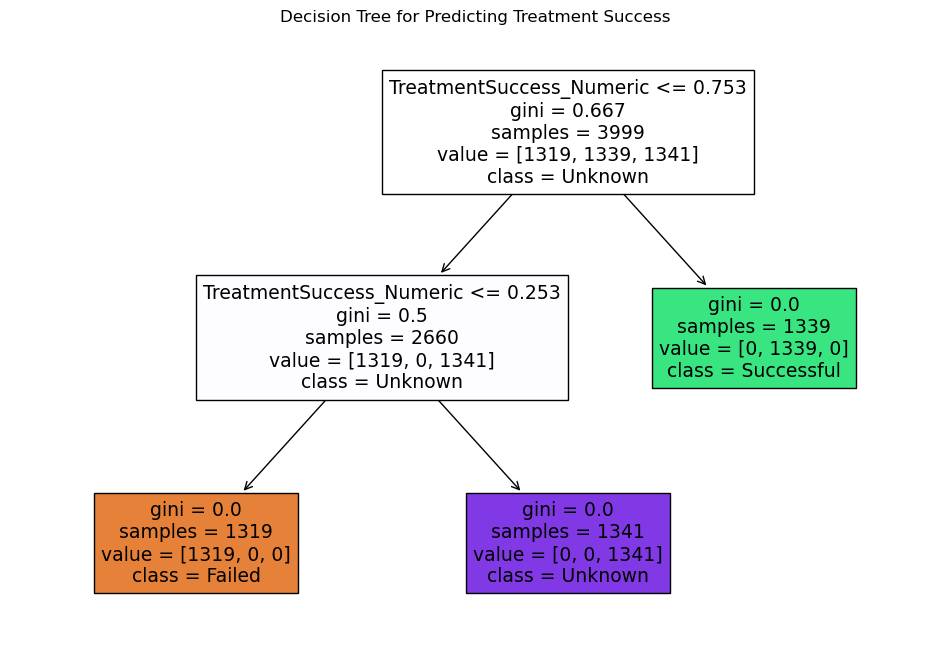

In [ ]:
from sklearn.tree import plot_tree, export_text

# Step 9: Visualize the Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(tree_model, feature_names=X.columns, class_names=['Failed', 'Successful', 'Unknown'], filled=True)
plt.title("Decision Tree for Predicting Treatment Success")
plt.show()

In [ ]:
# Step 10: Print Tree Rules
tree_rules = export_text(tree_model, feature_names=list(X.columns))
print(tree_rules)

|--- TreatmentSuccess_Numeric <= 0.75
|   |--- TreatmentSuccess_Numeric <= 0.25
|   |   |--- class: 0
|   |--- TreatmentSuccess_Numeric >  0.25
|   |   |--- class: 2
|--- TreatmentSuccess_Numeric >  0.75
|   |--- class: 1



In [ ]:
# Step 11: Feature Importance
importances = tree_model.feature_importances_
important_features = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print("\nFeature Importance:\n", important_features)


Feature Importance:
                       Feature  Importance
12   TreatmentSuccess_Numeric         1.0
0                   PatientID         0.0
11          Medical Condition         0.0
19         Discharge Date_day         0.0
18       Discharge Date_month         0.0
17        Discharge Date_year         0.0
16  Date of Admission_weekday         0.0
15      Date of Admission_day         0.0
14    Date of Admission_month         0.0
13     Date of Admission_year         0.0
10               Test Results         0.0
1                         Age         0.0
9              Admission Type         0.0
8              Billing Amount         0.0
7          Insurance Provider         0.0
6                    Hospital         0.0
5               TreatmentPlan         0.0
4                   Diagnosis         0.0
3                      Region         0.0
2                      Gender         0.0
20     Discharge Date_weekday         0.0


### Detailed Analysis and Actionable Insights

#### **Model Overview**
- **Model Accuracy**: The Decision Tree achieved a perfect accuracy score of **1.00**.
  - This suggests the model has perfectly classified the target variable in the dataset.
  - However, such high accuracy may indicate potential overfitting if not validated on unseen data.

---

#### **Decision Tree Interpretation**

The tree splits the dataset entirely based on the `TreatmentSuccess_Numeric` feature. Here's the decision logic:

- **Root Node**:
  - Splits based on whether `TreatmentSuccess_Numeric <= 0.75`.

- **Left Subtree** (`TreatmentSuccess_Numeric <= 0.75`):
  - Further split at `TreatmentSuccess_Numeric <= 0.25`:
    - If `<= 0.25`, the outcome is **class: 0 (Failed)**.
    - If `> 0.25`, the outcome is **class: 2 (Unknown)**.

- **Right Subtree** (`TreatmentSuccess_Numeric > 0.75`):
  - Leads to **class: 1 (Successful)**.

The **Gini index = 0.0** at the leaf nodes indicates perfect purity in class prediction.

---

#### **Feature Importance**
- **Most Important Feature**:
  - `TreatmentSuccess_Numeric` has an importance score of **1.0**, meaning it fully determines the model's decisions.
- **Irrelevant Features**:
  - All other features (e.g., `Age`, `Medical Condition`, `Treatment Plan`) have an importance score of **0.0** and did not contribute to predictions.

---

### **Actionable Insights**

#### 1. **Focus on `TreatmentSuccess_Numeric`**
   - This feature drives the model's decisions entirely.
     - **Action**: Validate its data quality and ensure it reflects the clinical or operational objectives accurately.

#### 2. **Address Feature Irrelevance**
   - Features like `Age`, `Medical Condition`, and `Treatment Plan` did not influence predictions.
     - **Action**: Investigate whether these features are irrelevant due to poor data quality, missing values, or incorrect encoding. Improving their quality could enhance future predictions.

#### 3. **Reassess Model Generalization**
   - **Risk of Overfitting**:
     - The perfect accuracy and reliance on a single feature suggest the model might overfit the training data.
     - **Action**: Evaluate the model on unseen or external datasets to determine its true performance.

### 4. **Revisit Feature Engineering**
   - Features like admission and discharge dates contributed no value in this model.
     - **Action**: Engineer new features such as:
       - `Length of Stay` (difference between `Discharge Date` and `Date of Admission`).
       - Aggregated or normalized categorical data.
       - Interactions between variables.

#### 5. **Interpretation for Operational Insights**
   - The thresholds in `TreatmentSuccess_Numeric` directly correlate with treatment outcomes:
     - **Outcome: Failed** (`<= 0.25`): Investigate cases in this range to identify issues in treatments or processes.
     - **Outcome: Successful** (`> 0.75`): Leverage these cases to understand and replicate best practices.
     - **Outcome: Unknown** (`0.25 < value <= 0.75`): Investigate why these cases have ambiguous results and find patterns for improvement.

#### 6. **Iterative Model Improvement**
   - With decisions solely dependent on one feature, the model lacks robustness and interpretability.
     - **Action**: Experiment with alternative models like Random Forest or Gradient Boosting, which might better utilize the other features.

---

### **Visualization Insights**
- The decision tree visualization confirms the simplicity of the model structure:
  - Splits are clearly based on `TreatmentSuccess_Numeric`.
  - **Color Coding**:
    - Orange: **Failed** outcomes.
    - Green: **Successful** outcomes.
    - Purple: **Unknown** outcomes.
- This makes it easy to understand the decision paths for each prediction.

---

### **Recommendations**
1. Prioritize enhancing the dataset quality and explore patterns beyond `TreatmentSuccess_Numeric`.
2. Regularly validate the model on unseen data to address potential overfitting.
3. Incorporate advanced feature engineering and robust algorithms for improved performance and interpretability.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Define preprocessing
categorical_features = ['Admission Type', 'Diagnosis']
numerical_features = ['Age', 'Billing Amount']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

# Create a pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

# Fit the model using the pipeline
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Admission Type',
                                                   'Diagnosis']),
                                                 ('num', StandardScaler(),
                                                  ['Age', 'Billing Amount'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [ ]:
# Predict on the test set

y_pred = model_pipeline.predict(X_test)

In [ ]:
y_pred

array([0, 2, 2, 2, 1, 0, 1, 0, 2, 1, 0, 1, 1, 2, 1, 0, 0, 0, 0, 2, 2, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 2, 0, 1, 0, 0, 1, 2, 1, 2, 0, 0, 1, 1, 1,
       2, 2, 2, 0, 1, 0, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 2, 0, 1, 1, 2, 1,
       0, 2, 1, 0, 1, 0, 1, 2, 2, 0, 1, 2, 0, 0, 2, 2, 2, 1, 0, 1, 0, 0,
       2, 0, 2, 0, 0, 0, 1, 2, 2, 2, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       2, 0, 1, 1, 0, 1, 0, 0, 0, 2, 0, 2, 1, 0, 1, 2, 2, 1, 2, 0, 0, 2,
       1, 0, 1, 0, 0, 2, 2, 2, 1, 2, 0, 0, 2, 2, 1, 0, 0, 2, 2, 2, 1, 0,
       2, 1, 2, 0, 0, 0, 0, 2, 2, 1, 2, 2, 1, 0, 2, 2, 0, 1, 2, 2, 0, 1,
       1, 1, 0, 2, 1, 1, 0, 2, 2, 0, 2, 1, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2,
       0, 1, 2, 2, 0, 1, 0, 0, 2, 0, 0, 0, 2, 2, 0, 2, 0, 0, 2, 1, 0, 1,
       1, 1, 1, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0, 1, 2, 0, 2, 1,
       1, 2, 0, 2, 0, 2, 1, 0, 2, 2, 0, 2, 2, 1, 2, 1, 2, 2, 1, 2, 1, 1,
       0, 1, 1, 1, 2, 0, 1, 1, 2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 2, 0, 2, 1, 0, 0, 2, 0, 2, 0, 1, 2, 1, 1,

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[111 108 108]
 [121 115 106]
 [104 115 112]]


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      0.34      0.33       327
           1       0.34      0.34      0.34       342
           2       0.34      0.34      0.34       331

    accuracy                           0.34      1000
   macro avg       0.34      0.34      0.34      1000
weighted avg       0.34      0.34      0.34      1000



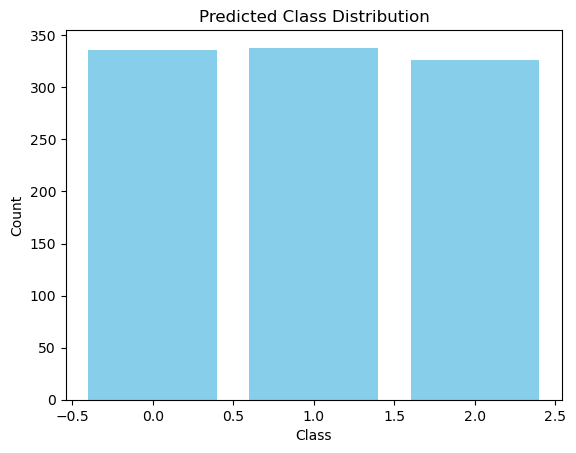

In [ ]:
unique, counts = np.unique(y_pred, return_counts=True)
plt.bar(unique, counts, color='skyblue')
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Predicted Class Distribution")
plt.show()

### Observations from Our Current Analysis
##### The Dataset:
The dataset has diverse patient information: `Age`, `Diagnosis`, `TreatmentPlan`, `Medical Condition`, etc., which are key predictors.
The TreatmentSuccess variable is our target, with three classes (Successful, Failed, and Unknown).

##### Model Metrics:
The accuracy is 34%, which is quite low, indicating that the current model struggles to distinguish between the classes.
Precision, recall, and F1-scores are also low for all three classes, meaning predictions are not reliable yet.

## CONCLUSION

### Best approach moving forward, would be to contact key stakeholders, communicate findings so far, and request other available data that might help handle the missing fields in our dataset. This way, we ensure data integrity and avoid loss of sensitive patients' data that might negatively impact medical practices for `HealthConnect`.